In [3]:
import sys; sys.path.append("..")          # cho notebook thấy thư mục src/
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load, TARGET, FEATURE_COLS, LEAKAGE_COLS

df = load()
print(df.shape)
base_rate = df[TARGET].mean()
print("Tỉ lệ sống tổng thể:", round(base_rate, 3))   # đường cơ sở

Matplotlib is building the font cache; this may take a moment.


(59603, 51)
Tỉ lệ sống tổng thể: 0.582


EDA đang xác định các yếu tố liên quan tới việc gói sống ≥6 tháng, và kiểm tra xem mối liên quan đó là thật hay do biến gây nhiễu.

In [4]:
print("Dòng trùng:", df.duplicated().sum())
# xem vài dòng trùng để quyết có bỏ không:
# df[df.duplicated(keep=False)].sort_values(by=____).head(10)

# tỉ lệ thiếu mỗi cột, sắp giảm dần:
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].round(3))

Dòng trùng: 935
TV360_WATCH_DURATION          1.000
TOTAL_TV360_MB                1.000
IS_TV360_THUC                 1.000
GOI_N1N2                      0.820
CHUKY_GOI_N1N2                0.764
GOI_DK_GIAHAN_PHANBO_TN1N2    0.723
GROUP_CHANNEL_TYPE_ID         0.684
STAFF_CODE_DN                 0.680
NUM_TT_BAT_MAY                0.680
USER_CUM_TRUONG               0.113
TINH_USER_DANG_KY_CU          0.092
CHUKY_GOI_N                   0.082
IS_3K3D                       0.079
TONG_TIEU_DUNG_N_1            0.079
TONG_TIEU_DUNG_N_2            0.059
TONG_TIEU_DUNG_N_3            0.057
HOME_TRAM                     0.003
TONG_CUOC_GOC_THUC            0.001
TONG_TIEU_DUNG_N              0.001
NGAY_KICH_HOAT                0.001
HOME_TINH                     0.001
HOME_HUYEN                    0.001
KENH_DANG_KY                  0.000
dtype: float64


In [5]:
def survival_by(col):
    """Tỉ lệ gói sống theo từng giá trị của 'col', kèm số lượng."""
    g = df.groupby(col)[TARGET].agg(["mean", "count"])
    g = g.rename(columns={"mean": "ti_le_song", "count": "so_luong"})
    return g.sort_values("ti_le_song", ascending=False)

# thử ngay:
print(survival_by("KENH_DANG_KY"))

              ti_le_song  so_luong
KENH_DANG_KY                      
OTHER           0.908629       197
HKD             0.639931     49435
CHTT            0.355263      4028
CHUQ            0.294820      4189
CHUOI           0.124710      1724
SME             0.034483        29


In [37]:
df["is_out_of_province"] = (df["HOME_TINH"] != "THA").astype(int)
print(survival_by("is_out_of_province"))

                    ti_le_song  so_luong
is_out_of_province                      
1                     0.808966     51373
0                     0.467262    110604


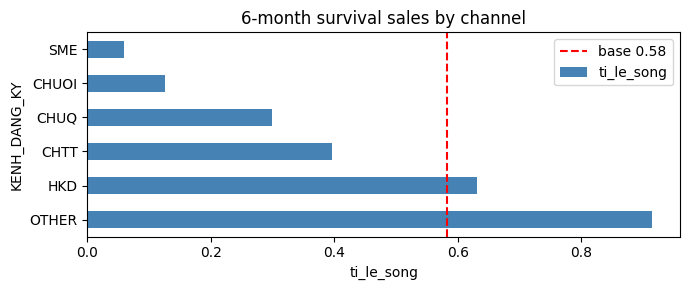

In [35]:
import matplotlib.pyplot as plt

ax = survival_by("KENH_DANG_KY")["ti_le_song"].plot(
    kind="barh", figsize=(7,3), color="steelblue")
ax.axvline(base_rate, color="red", ls="--", label=f"base {base_rate:.2f}")
ax.set_title("6-month survival sales by channel")
ax.set_xlabel("ti_le_song"); ax.legend()
plt.tight_layout(); plt.show()

Sales channel strongly separates retention. 6-month survival ranges from 0.12 (CHUOI) to 0.64 (HKD) against a 0.58 baseline. HKD also carries ~83% of all sales, so it anchors healthy revenue; CHUOI/CHUQ/CHTT concentrate at-risk plans. (OTHER and SME are ignored — sample sizes of 197 and 29 are too small to trust.) 

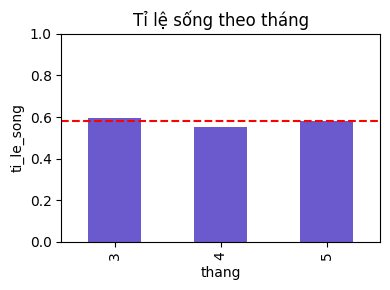

In [30]:
df.groupby("thang")["TUOI_THO_6THANG"].mean().plot(
    kind="bar", figsize=(4,3), color="slateblue")
plt.axhline(base_rate, color="red", ls="--")
plt.title("Tỉ lệ sống theo tháng"); plt.ylim(0,1)
plt.ylabel("ti_le_song"); plt.tight_layout(); plt.show()

Label rate is stable across months (0.55–0.60 for Mar/Apr/May), confirming a consistent label definition. This validates merging the three months for out-of-time validation rather than introducing a hidden inconsistency. 

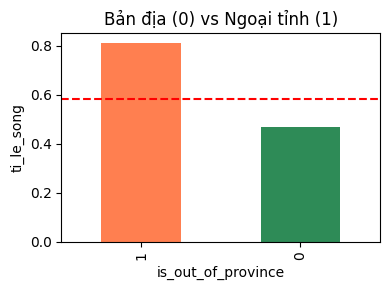

In [38]:
survival_by("is_out_of_province")["ti_le_song"].plot(
    kind="bar", figsize=(4,3), color=["coral","seagreen"])
plt.axhline(base_rate, color="red", ls="--")
plt.title("Bản địa (0) vs Ngoại tỉnh (1)")
plt.ylabel("ti_le_song"); plt.tight_layout(); plt.show()

Out-of-province subscribers are stickier, not riskier. They survive at 0.79 vs 0.49 for locals — rejecting the initial hypothesis that migrants churn faster. The gap is large and both groups are well-sized, so it is a real association (causation checked below).

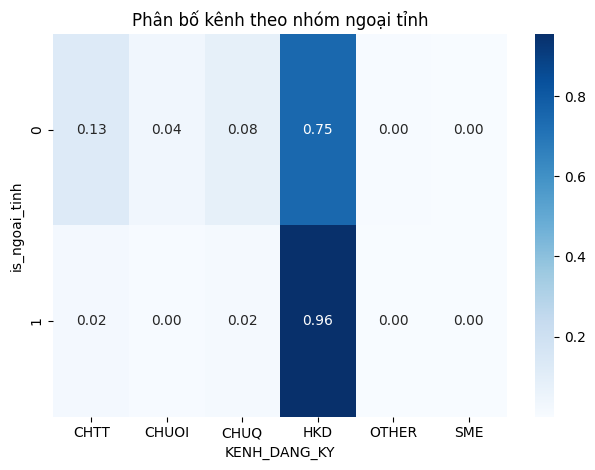

In [29]:
import seaborn as sns
ct = pd.crosstab(df["is_ngoai_tinh"], df["KENH_DANG_KY"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Phân bố kênh theo nhóm ngoại tỉnh")
plt.tight_layout(); plt.show()

Confounding confirmed: out-of-province subscribers buy almost exclusively via HKD (96%), the highest-retention channel, while locals spread into low-retention channels (CHUOI/CHUQ). The raw 0.79-vs-0.49 gap is largely driven by channel mix, not residence itself — motivating a multivariate model over pairwise comparisons.



### EDA summary
- Channel is the strongest single signal for 6-month retention (0.12 → 0.64).
- Out-of-province subscribers appear stickier (0.79 vs 0.49) but the effect is confounded by channel (96% buy via HKD).
- Label rate is stable across months → safe to merge Mar–May for out-of-time validation.
- Single-variable associations are not causal and overlap with each other; a multivariate model is needed to weigh signals jointly. → Phase 3.

Note: EDA used all columns freely for exploration; the leakage rules in columns.yaml apply only to model features.